# DL084 序贯决策与策略梯度桥接

本Notebook使用真实Python内核顺序运行。先读lecture.md与lab.md。只验证明确限定的离线教学机制，不代表真实LLM性能。

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import experiment as exp
print("Python",sys.version.split()[0],"NumPy",np.__version__)

Python 3.12.14 NumPy 2.3.5


## 完整实验与真实输出
运行会在本目录outputs写入可复核结果。

In [2]:
result=exp.main()
print(json.dumps(result,ensure_ascii=False,indent=2))

{
  "seed": 84,
  "mdp": {
    "theta": [
      0.2,
      -0.4,
      0.7
    ],
    "gamma": 0.9,
    "exact_return": 0.36496209527113255,
    "exact_gradient": [
      0.07500115091217585,
      0.02920244926856056,
      0.10971474784054659
    ],
    "mc_gradient": [
      0.07340212583479505,
      0.029467836970458634,
      0.1089667043112809
    ],
    "mc_standard_error": [
      0.0009996480891262636,
      0.00039821544072747285,
      0.0005402538429550079
    ],
    "variance_no_baseline": [
      0.04996481510468952,
      0.007928776861688771,
      0.014593710741382713
    ],
    "variance_constant_baseline": [
      0.02279377994364817,
      0.0024283115586787255,
      0.013344375011202064
    ],
    "trained_return": 0.7698851808004306
  },
  "bandit": {
    "exact_return": 0.5446655100869955,
    "exact_gradient": 0.14667498701444753,
    "mc_gradient": 0.146433282871556,
    "variance_no_baseline": 0.08985668495666435,
    "variance_baseline_half": 0.039406230540

## 单步手算

In [3]:
print("theta=0",exp.bandit_exact(0))
print("theta=0.3",exp.bandit_exact(.3))

theta=0 (0.5, 0.15000000000000002)
theta=0.3 (0.5446655100869955, 0.14667498701444753)


## 四条轨迹

In [4]:
theta=np.array([.2,-.4,.7])
for row in exp.enumerate_mdp(theta): print(row)
print("exact",exp.mdp_exact(theta))

{'a0': 0, 'a1': 0, 'probability': 0.26950883081116833, 'return': 0.09000000000000001, 'score': array([-0.549834  , -0.40131234,  0.        ])}
{'a0': 0, 'a1': 1, 'probability': 0.1806571718763537, 'return': 0.36000000000000004, 'score': array([-0.549834  ,  0.59868766,  0.        ])}
{'a0': 1, 'a1': 0, 'probability': 0.1824416435859359, 'return': -0.1, 'score': array([ 0.450166  ,  0.        , -0.66818777])}
{'a0': 1, 'a1': 1, 'probability': 0.36739235372654205, 'return': 0.8, 'score': array([0.450166  , 0.        , 0.33181223])}
exact (0.36496209527113255, array([0.07500115, 0.02920245, 0.10971475]))


## 基线与离策略

In [5]:
g0=exp.mdp_mc(theta,baseline=0)
g1=exp.mdp_mc(theta,baseline=exp.mdp_exact(theta)[0])
print("variance before",g0.var(0))
print("variance after",g1.var(0))
print(exp.importance_bandit(.3,-1.3))

variance before [0.04996382 0.00792862 0.01459342]
variance after [0.02279332 0.00242826 0.01334411]
{'uncorrected': -0.018335831588769187, 'importance_corrected': 0.14577757956507606, 'max_ratio': 2.682242529487491, 'effective_sample_size': 28232.326597264524}


## 全部单元测试
同时检查边界与失败路径，不只观察损失下降。

In [6]:
import unittest
suite=unittest.defaultTestLoader.discover(str(Path.cwd()),pattern="test_experiment.py")
check=unittest.TextTestRunner(verbosity=2).run(suite)
if not check.wasSuccessful(): raise RuntimeError("tests failed")

test_bandit_gradient (test_experiment.Tests.test_bandit_gradient) ... 

ok


test_baseline_expectation (test_experiment.Tests.test_baseline_expectation) ... 

ok


test_discount_zero (test_experiment.Tests.test_discount_zero) ... 

...

test_score_mean_zero (test_experiment.Tests.test_score_mean_zero) ... 

ok


test_sigmoid (test_experiment.Tests.test_sigmoid) ... 

ok


----------------------------------------------------------------------
Ran 13 tests in 0.070s

OK


## 从输出重建原创图
图的数值来自本次实验，不是示意数字。

figure count 4


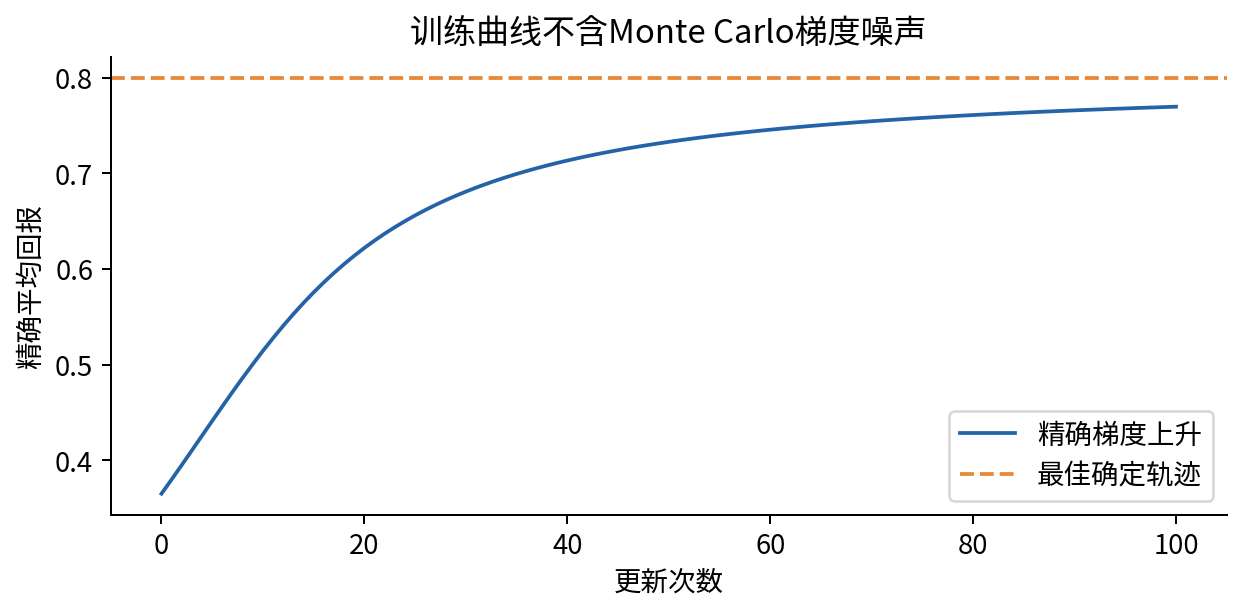

In [7]:
import make_figures
make_figures.main()
from IPython.display import display, Image
figures=sorted(Path("figures").glob("*.png"))
print("figure count",len(figures))
display(Image(filename=str(figures[-1])))

## 研究记录
写下一个受支持结论、一个失败/限制，以及下一步需要的新证据。参考答案在answers.md，不能用参考结论替代你自己的检查。

In [8]:
print("Output files:",sorted(p.name for p in Path("outputs").iterdir() if p.is_file()))

Output files: ['environment.json', 'gradient_samples.npz', 'history.json', 'metrics.json', 'notebook-execution.json', 'replay-comparison.json', 'trajectories.json']
